In [1]:
import os
import random
import sys
import cv2
import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
import os
os.chdir('/workspace')

In [3]:
BASE_PATH = '/workspace/vindr_mammogram'
IMG_DIR = os.path.join(BASE_PATH, 'mammo_processed_merged1') 
df=pd.read_csv(f'{IMG_DIR}/mammo_processed_merged.csv')
df = df[df['cc_breast_birads'].isin(['BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'])]

df.head()

,study_id,laterality,merged_image_path,cc_image_id,mlo_image_id,split,cc_image_path,mlo_image_path,has_cc_bbox,has_mlo_bbox,...,cc_crop_coords,mlo_crop_coords,cc_breast_birads,mlo_breast_birads,cc_breast_density,mlo_breast_density,cc_finding_categories,mlo_finding_categories,cc_finding_birads,mlo_finding_birads
6,003700f3c960e0b9bca2b8437c3dbf05,L,vindr_original_data/mammo_processed_merged1/00...,51b47f9024ccad1356354f56ac916f29,3944b33b99c98e763763b9da54b4f41c,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,True,True,...,"(0, 0, 740, 1713)","(0, 0, 781, 2162)",BI-RADS 4,BI-RADS 4,DENSITY C,DENSITY C,['Suspicious Calcification'],['Suspicious Calcification'],BI-RADS 4,BI-RADS 4
19,008b8e61390fcb4c0873258c15b0a53a,R,vindr_original_data/mammo_processed_merged1/00...,f1f79501410a98782c0a03b48e66df83,e13c80239d7714e3d964b5f3e37bcff6,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,True,True,...,"(0, 49, 711, 1683)","(0, 0, 756, 2286)",BI-RADS 4,BI-RADS 4,DENSITY C,DENSITY C,['Mass'],"['Suspicious Calcification', 'Mass']",BI-RADS 4,BI-RADS 4
22,00a369b4ec1e5e0ff34e6bd838e5f2d6,L,vindr_original_data/mammo_processed_merged1/00...,f3cbed97f4bb7897467e1e8bab45966e,2feab51140b38f9ec90e17b7006501b2,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,True,...,"(0, 0, 1124, 2174)","(0, 0, 1101, 2761)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['No Finding'],['Mass'],NaN,BI-RADS 3
50,012e0595adba5173b6e60a97f9e84b6e,L,vindr_original_data/mammo_processed_merged1/01...,f6c7f3c3e03d612002800f20b1282309,edb7f6e44809405ec40a9c2537da62e6,training,vindr_original_data/mammo_processed_cropped/01...,vindr_original_data/mammo_processed_cropped/01...,True,True,...,"(0, 0, 1004, 1924)","(0, 0, 965, 2588)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['Mass'],['Mass'],BI-RADS 3,BI-RADS 3
51,012e0595adba5173b6e60a97f9e84b6e,R,vindr_original_data/mammo_processed_merged1/01...,202d1c29785f6327985ffda7100e2265,7adeb584564fc161d897a3fc719acd17,training,vindr_original_data/mammo_processed_cropped/01...,vindr_original_data/mammo_processed_cropped/01...,True,True,...,"(0, 9, 1034, 1969)","(10, 0, 993, 2727)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['Mass'],['Mass'],BI-RADS 3,BI-RADS 3


In [4]:
def get_combined_finding_6class(cc_findings, mlo_findings, cc_birads, mlo_birads):
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    def parse_birads(birads_str):
        if pd.isna(birads_str) or birads_str == '':
            return 0
        if isinstance(birads_str, str):
            try:
                return int(birads_str.strip().split()[-1])
            except:
                return 0
        return int(birads_str)
    
    cc_birads_num = parse_birads(cc_birads)
    mlo_birads_num = parse_birads(mlo_birads)
    max_birads = max(cc_birads_num, mlo_birads_num)
    
    if not all_findings or all_findings == {'No Finding'}:
        if max_birads == 1:
            return 0
        elif max_birads == 2:
            return 0
        else:
            return 1 if max_birads == 3 else 4
    
    if has_structural:
        return 4
    
    if has_mass and has_calc:
        return 3
    
    if has_mass:
        return 2
    
    if has_calc:
        return 1
    
    if has_lymph:
        return 3
    
    if has_asymmetry and len(all_findings) == 1:
        return -1
    
    if has_asymmetry and len(all_findings) > 1:
        return 4
    
    print(f"Warning: Unknown finding combination: {all_findings}, BIRADS: {max_birads}")
    return 4

df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['cc_finding_categories'], 
        row['mlo_finding_categories'],
        row['cc_breast_birads'],
        row['mlo_breast_birads']
    ),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts().sort_index()

finding
1    132
2    490
3     65
4     83
Name: count, dtype: int64

In [5]:
df['mlo_finding_categories'].value_counts()


mlo_finding_categories
['Mass']                                                                                            483
['Suspicious Calcification']                                                                        130
['Architectural Distortion']                                                                         43
['Suspicious Calcification', 'Mass']                                                                 33
['Suspicious Lymph Node']                                                                            21
['Suspicious Calcification', 'Focal Asymmetry']                                                       9
['No Finding']                                                                                        9
['Asymmetry']                                                                                         5
['Suspicious Calcification', 'Architectural Distortion']                                              5
['Skin Thickening']                      

In [6]:
df_no_finding = df[df['cc_finding_categories'] == "['No Finding']"]

In [7]:
df_no_finding.head()

,study_id,laterality,merged_image_path,cc_image_id,mlo_image_id,split,cc_image_path,mlo_image_path,has_cc_bbox,has_mlo_bbox,...,mlo_crop_coords,cc_breast_birads,mlo_breast_birads,cc_breast_density,mlo_breast_density,cc_finding_categories,mlo_finding_categories,cc_finding_birads,mlo_finding_birads,finding
22,00a369b4ec1e5e0ff34e6bd838e5f2d6,L,vindr_original_data/mammo_processed_merged1/00...,f3cbed97f4bb7897467e1e8bab45966e,2feab51140b38f9ec90e17b7006501b2,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,True,...,"(0, 0, 1101, 2761)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['No Finding'],['Mass'],NaN,BI-RADS 3,2
258,0676f4386325058f95263c823b0ee347,L,vindr_original_data/mammo_processed_merged1/06...,f792b9d57722dd5d5ac34e3772e6afbc,77f6c807dcdbd4f5b9305219fa5d9779,training,vindr_original_data/mammo_processed_cropped/06...,vindr_original_data/mammo_processed_cropped/06...,False,True,...,"(0, 0, 958, 2662)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['No Finding'],['Mass'],NaN,BI-RADS 3,2
579,0f0551f4edb5494b0d8765c23fe421ae,R,vindr_original_data/mammo_processed_merged1/0f...,bef2aebeeee11a80478eb621fa6666d8,a37e508fc994c1c7a846ec23edfb400f,training,vindr_original_data/mammo_processed_cropped/0f...,vindr_original_data/mammo_processed_cropped/0f...,False,True,...,"(12, 0, 1063, 2688)",BI-RADS 4,BI-RADS 4,DENSITY B,DENSITY B,['No Finding'],['Mass'],NaN,BI-RADS 4,2
592,0f73f59df0d9355ebe1d6024753a9e1b,L,vindr_original_data/mammo_processed_merged1/0f...,c0cd071eeccaa65eeeb32ad9c62ee959,18b6303a3ede8d3556f87dada8d64c49,training,vindr_original_data/mammo_processed_cropped/0f...,vindr_original_data/mammo_processed_cropped/0f...,False,True,...,"(0, 0, 1256, 2623)",BI-RADS 4,BI-RADS 4,DENSITY C,DENSITY C,['No Finding'],['Mass'],NaN,BI-RADS 4,2
973,1a1fab4e6eb9512e6eda9d1d2cfda26b,R,vindr_original_data/mammo_processed_merged1/1a...,2ac008d751dbe9d70d86a82e6544928e,129b633979a43461369df710e69e111d,training,vindr_original_data/mammo_processed_cropped/1a...,vindr_original_data/mammo_processed_cropped/1a...,False,True,...,"(10, 0, 1105, 2614)",BI-RADS 3,BI-RADS 3,DENSITY C,DENSITY C,['No Finding'],['Mass'],NaN,BI-RADS 3,2


In [8]:
df.columns

Index(['study_id', 'laterality', 'merged_image_path', 'cc_image_id',
       'mlo_image_id', 'split', 'cc_image_path', 'mlo_image_path',
       'has_cc_bbox', 'has_mlo_bbox', 'merged_cc_bbox', 'merged_mlo_bbox',
       'original_cc_bbox', 'original_mlo_bbox', 'cc_crop_coords',
       'mlo_crop_coords', 'cc_breast_birads', 'mlo_breast_birads',
       'cc_breast_density', 'mlo_breast_density', 'cc_finding_categories',
       'mlo_finding_categories', 'cc_finding_birads', 'mlo_finding_birads',
       'finding'],
      dtype='str')

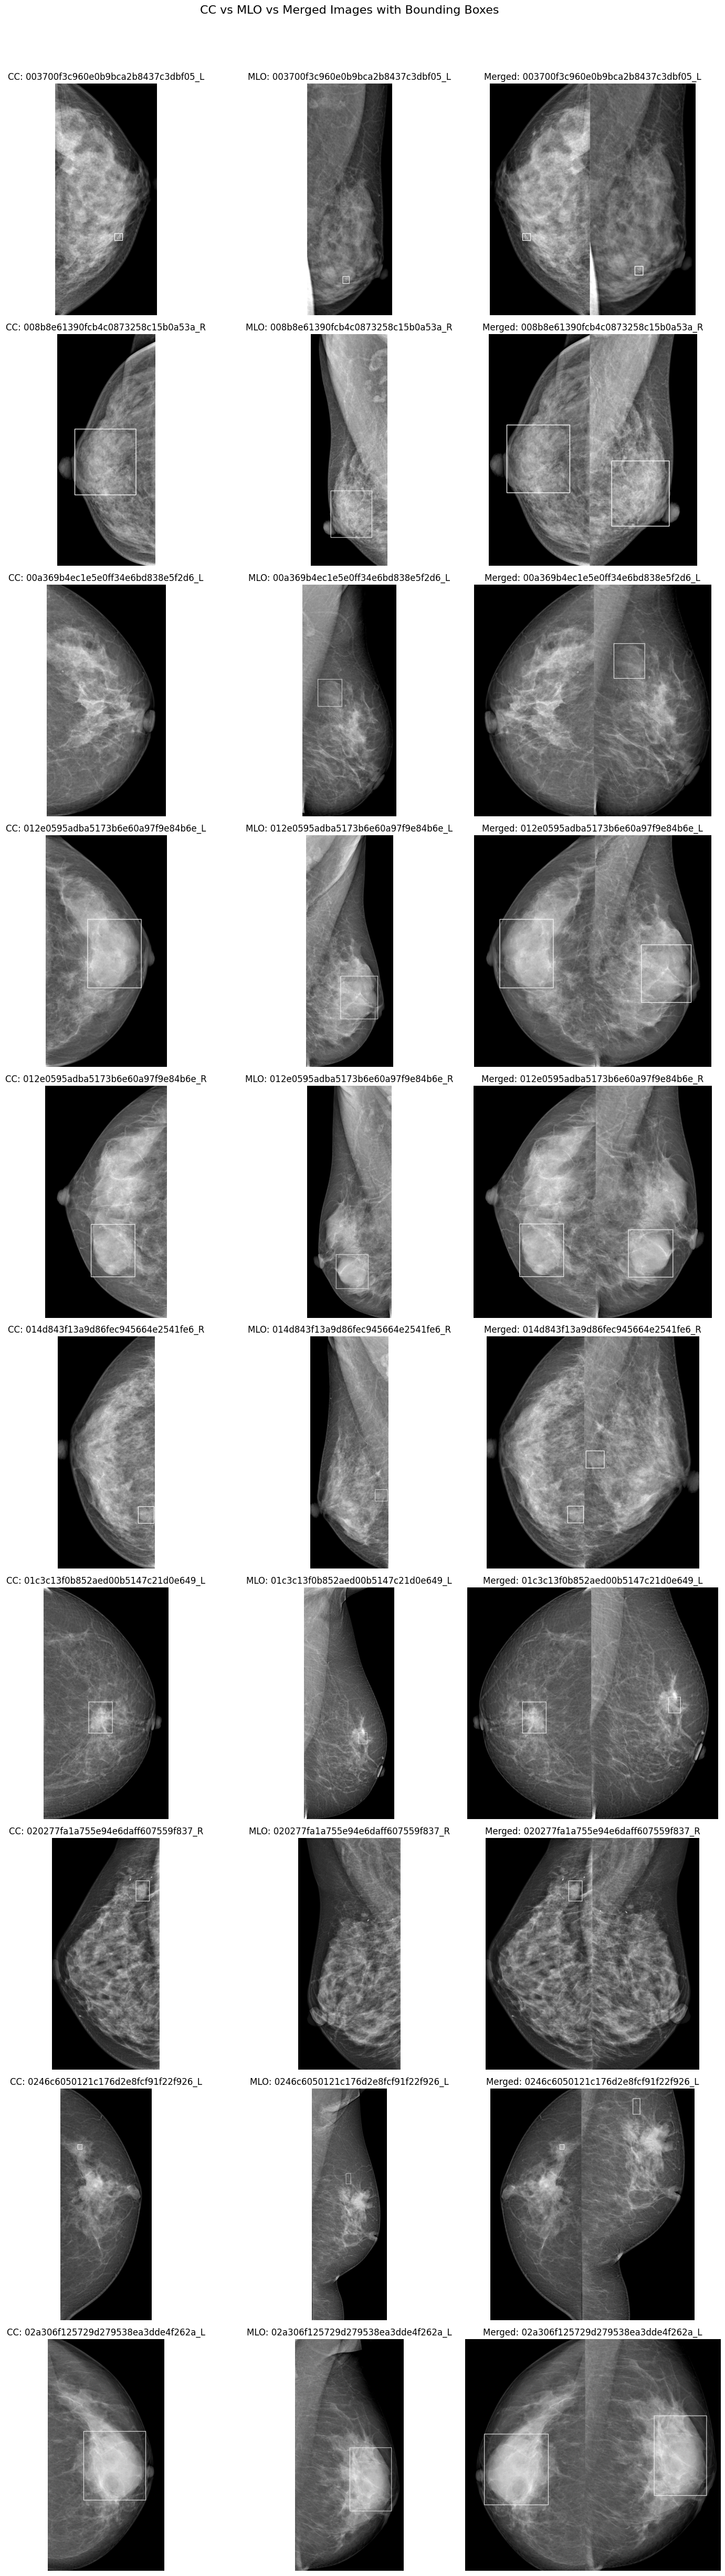

In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def display_merged_comparison(merged_csv_path, num_images=10):
    """Display comparison of CC, MLO and merged images with bounding boxes"""
    # Read the merged CSV file
    df = pd.read_csv(merged_csv_path)
    df["merged_image_path"] = (
        df["merged_image_path"]
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    )
    df["cc_image_path"] = (
    df["cc_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    df["mlo_image_path"] = (
    df["mlo_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    # Filter for images with bounding boxes in either CC or MLO
    has_bbox = df['has_cc_bbox'] | df['has_mlo_bbox']
    df_with_bbox = df[has_bbox]
    
    # Get the first num_images with bounding boxes
    sample_images = df_with_bbox.head(num_images)
    
    # Create figure for display - num_images rows, 3 columns
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5*num_images))
    
    fig.suptitle('CC vs MLO vs Merged Images with Bounding Boxes', fontsize=16)
    
    for i, (_, row) in enumerate(sample_images.iterrows()):
        if i >= num_images:
            break
            
        study_id = row['study_id']
        laterality = row['laterality']
        
        # Load CC image and draw bbox
        cc_img_path = row['cc_image_path']
        cc_img = cv2.imread(cc_img_path, cv2.IMREAD_GRAYSCALE)
        
        # Draw CC bounding box if available
        cc_with_bbox = cc_img.copy()
        if row['has_cc_bbox'] and pd.notna(row['original_cc_bbox']):
            # Parse bbox from string format "[xmin, ymin, xmax, ymax]"
            bbox_str = row['original_cc_bbox'].strip('[]')
            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
            cc_with_bbox = cv2.rectangle(cc_img.copy(), (xmin, ymin), (xmax, ymax), (255, 255, 255), 3)
        
        # Load MLO image and draw bbox
        mlo_img_path = row['mlo_image_path']
        mlo_img = cv2.imread(mlo_img_path, cv2.IMREAD_GRAYSCALE)
        
        # Draw MLO bounding box if available
        mlo_with_bbox = mlo_img.copy()
        if row['has_mlo_bbox'] and pd.notna(row['original_mlo_bbox']):
            # Parse bbox from string format "[xmin, ymin, xmax, ymax]"
            bbox_str = row['original_mlo_bbox'].strip('[]')
            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
            mlo_with_bbox = cv2.rectangle(mlo_img.copy(), (xmin, ymin), (xmax, ymax), (255, 255, 255), 3)
        
        # Load merged image and draw bboxes
        merged_img_path = row['merged_image_path']
        merged_img = cv2.imread(merged_img_path, cv2.IMREAD_GRAYSCALE)
        
        # Draw CC bbox on merged image if available
        merged_with_bbox = merged_img.copy()
        if row['has_cc_bbox'] and pd.notna(row['merged_cc_bbox']):
            # Parse bbox from string format "[xmin, ymin, xmax, ymax]"
            bbox_str = row['merged_cc_bbox'].strip('[]')
            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
            merged_with_bbox = cv2.rectangle(merged_img.copy(), (xmin, ymin), (xmax, ymax), (255, 255, 255), 3)
        
        # Draw MLO bbox on merged image if available
        if row['has_mlo_bbox'] and pd.notna(row['merged_mlo_bbox']):
            # Parse bbox from string format "[xmin, ymin, xmax, ymax]"
            bbox_str = row['merged_mlo_bbox'].strip('[]')
            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
            merged_with_bbox = cv2.rectangle(merged_with_bbox, (xmin, ymin), (xmax, ymax), (255, 255, 255), 3)
        
        # Display CC image in first column
        axes[i, 0].imshow(cc_with_bbox, cmap='gray')
        axes[i, 0].set_title(f'CC: {study_id}_{laterality}', fontsize=12)
        axes[i, 0].axis('off')
        
        # Display MLO image in second column
        axes[i, 1].imshow(mlo_with_bbox, cmap='gray')
        axes[i, 1].set_title(f'MLO: {study_id}_{laterality}', fontsize=12)
        axes[i, 1].axis('off')
        
        # Display merged image in third column
        axes[i, 2].imshow(merged_with_bbox, cmap='gray')
        axes[i, 2].set_title(f'Merged: {study_id}_{laterality}', fontsize=12)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Adjust for suptitle
    plt.show()

# Example usage
if __name__ == "__main__":
    merged_csv_path = "/workspace/vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv"
    display_merged_comparison(merged_csv_path, num_images=10)

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import shutil
from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import train_test_split

def validate_bbox(bbox):
    """Validate and fix bounding box coordinates to ensure they stay within [0.0, 1.0]"""
    x_center, y_center, width, height = bbox
    
    # Ensure width and height are positive and reasonable
    width = max(0.001, min(1.0, width))  # Minimum 0.1% of image size
    height = max(0.001, min(1.0, height))
    
    # Calculate boundaries
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2
    
    # Clamp boundaries to [0.0, 1.0]
    x_min = max(0.0, min(0.999, x_min))
    y_min = max(0.0, min(0.999, y_min))
    x_max = max(0.001, min(1.0, x_max))
    y_max = max(0.001, min(1.0, y_max))
    
    # Ensure min < max
    x_min, x_max = min(x_min, x_max), max(x_min, x_max)
    y_min, y_max = min(y_min, y_max), max(y_min, y_max)
    
    # Recalculate center and dimensions
    new_width = x_max - x_min
    new_height = y_max - y_min
    new_x_center = x_min + new_width / 2
    new_y_center = y_min + new_height / 2
    
    # Final validation
    new_x_center = max(0.0, min(1.0, new_x_center))
    new_y_center = max(0.0, min(1.0, new_y_center))
    new_width = max(0.001, min(1.0, new_width))
    new_height = max(0.001, min(1.0, new_height))
    
    return [new_x_center, new_y_center, new_width, new_height]

def get_augmentation_pipeline():
    """
    Conservative augmentation pipeline for mammogram lesion detection.
    Designed to preserve medical characteristics while improving YOLO robustness.
    """

    return A.Compose([

        # -------------------------------------------------
        # CONTRAST / INTENSITY (VERY IMPORTANT FOR MAMMO)
        # -------------------------------------------------

        # CLAHE improves local contrast for masses/calcifications
        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8, 8),
            p=0.35
        ),

        # Mild brightness/contrast adjustment
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.12,
            p=0.30
        ),

        # Gamma variation
        A.RandomGamma(
            gamma_limit=(90, 110),
            p=0.30
        ),

        # -------------------------------------------------
        # NOISE (REALISTIC FOR MEDICAL IMAGING)
        # -------------------------------------------------

        # Mild gaussian noise
        A.GaussNoise(
            std_range=(0.01, 0.03),
            mean_range=(0.0, 0.0),
            p=0.20
        ),

        # Small multiplicative intensity variation
        A.MultiplicativeNoise(
            multiplier=(0.97, 1.03),
            per_channel=False,
            elementwise=False,
            p=0.15
        ),

        # -------------------------------------------------
        # GEOMETRIC TRANSFORMS
        # -------------------------------------------------

        # Small affine transform only
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.03, 0.03),
            rotate=(-5, 5),
            shear=(-2, 2),
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            cval=0,
            p=0.30
        ),

        # Horizontal flip only
        # DO NOT USE VERTICAL FLIP IN MAMMOGRAPHY
        A.HorizontalFlip(p=0.50),

        # -------------------------------------------------
        # BLUR
        # -------------------------------------------------

        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
        ], p=0.10),

        # -------------------------------------------------
        # OCCLUSION / REGULARIZATION
        # -------------------------------------------------

        # Mild coarse dropout
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(0.02, 0.05),
            hole_width_range=(0.02, 0.05),
            fill=0,
            p=0.10
        ),

    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.40,
        min_area=16
    ))

def convert_grayscale_to_rgb(image):
    """Convert grayscale image to 3-channel RGB"""
    if len(image.shape) == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif len(image.shape) == 3 and image.shape[2] == 1:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        return image

def convert_rgb_to_grayscale(image):
    """Convert RGB image back to grayscale for saving"""
    if len(image.shape) == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        return image

def apply_augmentations(image, bboxes, class_labels, aug_pipeline, num_augmentations=3):
    """
    Apply augmentations to an image and its bounding boxes with proper validation
    """
    augmented_data = []
    
    # Convert grayscale to RGB for augmentation
    image_rgb = convert_grayscale_to_rgb(image)
    
    # Pre-validate original bounding boxes
    validated_bboxes = []
    validated_class_labels = []
    
    for bbox, class_label in zip(bboxes, class_labels):
        validated_bbox = validate_bbox(bbox)
        # Only keep reasonably sized bounding boxes
        if validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01:
            validated_bboxes.append(validated_bbox)
            validated_class_labels.append(class_label)
    
    if not validated_bboxes:
        return augmented_data
    
    for i in range(num_augmentations):
        try:
            augmented = aug_pipeline(
                image=image_rgb,
                bboxes=validated_bboxes,
                class_labels=validated_class_labels
            )
            
            # Convert back to grayscale for saving
            augmented_gray = convert_rgb_to_grayscale(augmented['image'])
            
            # Validate and clamp augmented bounding boxes
            final_bboxes = []
            final_class_labels = []
            
            for bbox, class_label in zip(augmented['bboxes'], augmented['class_labels']):
                validated_bbox = validate_bbox(bbox)
                
                # Check if bounding box is still valid after augmentation
                if (validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01 and
                    validated_bbox[0] >= 0.0 and validated_bbox[0] <= 1.0 and
                    validated_bbox[1] >= 0.0 and validated_bbox[1] <= 1.0):
                    
                    final_bboxes.append(validated_bbox)
                    final_class_labels.append(class_label)
            
            # Only add augmentation if we have valid bounding boxes
            if final_bboxes:
                augmented_data.append({
                    'image': augmented_gray,
                    'bboxes': final_bboxes,
                    'class_labels': final_class_labels,
                    'aug_idx': i
                })
                
        except Exception as e:
            print(f"Augmentation {i} failed: {e}")
            continue
    
    return augmented_data

def create_yolo_datasets(merged_csv_path, output_base_dir, num_augmentations=3, test_size=0.2, random_state=42):
    """
    Create two YOLO datasets with augmentation:
    1. Single view dataset (CC and MLO separately)
    2. Merged view dataset (CC+MLO combined)
    """
    
    # Read the merged CSV file
    df = pd.read_csv(merged_csv_path)
    df["merged_image_path"] = (
        df["merged_image_path"]
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    )
    df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['cc_finding_categories'], 
        row['mlo_finding_categories'],
        row['cc_breast_birads'],
        row['mlo_breast_birads']
    ),
    axis=1
)
    df.drop(df[df['finding'] == -1].index, inplace=True)

    df["cc_image_path"] = (
    df["cc_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    df["mlo_image_path"] = (
    df["mlo_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    df = df[df['cc_breast_birads'].isin(['BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'])]
    
    # Create output directories
    single_view_dir = os.path.join(output_base_dir, "single_view")
    merged_view_dir = os.path.join(output_base_dir, "merged_view")
    
    # Create train and val directories for both datasets
    for dataset_dir in [single_view_dir, merged_view_dir]:
        for split in ['train', 'val']:
            os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
            os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)
    
    # BI-RADS to class mapping
    birads_to_class = {
        'BI-RADS 3': 0,
        'BI-RADS 4': 0,
        'BI-RADS 5': 0
    }
    
    # Check if 'split' column exists
    if 'split' in df.columns:
        train_df = df[df['split'] == 'training']
        test_df = df[df['split'] == 'test']
    else:
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=random_state,
            stratify=df['cc_breast_birads']
        )
    
    # Initialize augmentation pipeline
    aug_pipeline = get_augmentation_pipeline()
    
    # Process single view dataset
    print("Creating single view dataset with augmentations...")
    single_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Process CC view
            if row['has_cc_bbox'] and pd.notna(row['original_cc_bbox']):
                cc_img_path = row['cc_image_path']
                cc_img = cv2.imread(cc_img_path, cv2.IMREAD_GRAYSCALE)
                
                if cc_img is not None:
                    # Parse bbox
                    bbox_str = row['original_cc_bbox'].strip('[]')
                    xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                    
                    # Convert to YOLO format (normalized)
                    img_height, img_width = cc_img.shape
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height
                    
                    # Validate and clamp bounding box
                    bbox = validate_bbox([x_center, y_center, width, height])
                    x_center, y_center, width, height = bbox
                    
                    # Get class from BI-RADS
                    birads = str(row['cc_breast_birads'])
                    if birads in birads_to_class:
                        class_id = birads_to_class[birads]
                        
                        # Save original image and label
                        cc_filename = f"{study_id}_{laterality}_CC.png"
                        cc_output_path = os.path.join(single_view_dir, split_name, "images", cc_filename)
                        cv2.imwrite(cc_output_path, cc_img)
                        
                        label_filename = f"{study_id}_{laterality}_CC.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'CC',
                            'image_path': cc_output_path,
                            'label_path': label_output_path,
                            'birads': birads,
                            'class_id': class_id,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                cc_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_cc_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.png"
                                aug_cc_output_path = os.path.join(single_view_dir, split_name, "images", aug_cc_filename)
                                cv2.imwrite(aug_cc_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'CC',
                                    'image_path': aug_cc_output_path,
                                    'label_path': aug_label_output_path,
                                    'birads': birads,
                                    'class_id': class_id,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
            
            # Process MLO view
            if row['has_mlo_bbox'] and pd.notna(row['original_mlo_bbox']):
                mlo_img_path = row['mlo_image_path']
                mlo_img = cv2.imread(mlo_img_path, cv2.IMREAD_GRAYSCALE)
                
                if mlo_img is not None:
                    # Parse bbox
                    bbox_str = row['original_mlo_bbox'].strip('[]')
                    xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                    
                    # Convert to YOLO format (normalized)
                    img_height, img_width = mlo_img.shape
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height
                    
                    # Validate and clamp bounding box
                    bbox = validate_bbox([x_center, y_center, width, height])
                    x_center, y_center, width, height = bbox
                    
                    # Get class from BI-RADS
                    birads = str(row['mlo_breast_birads'])
                    if birads in birads_to_class:
                        class_id = birads_to_class[birads]
                        
                        # Save original image and label
                        mlo_filename = f"{study_id}_{laterality}_MLO.png"
                        mlo_output_path = os.path.join(single_view_dir, split_name, "images", mlo_filename)
                        cv2.imwrite(mlo_output_path, mlo_img)
                        
                        label_filename = f"{study_id}_{laterality}_MLO.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'MLO',
                            'image_path': mlo_output_path,
                            'label_path': label_output_path,
                            'birads': birads,
                            'class_id': class_id,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                mlo_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_mlo_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.png"
                                aug_mlo_output_path = os.path.join(single_view_dir, split_name, "images", aug_mlo_filename)
                                cv2.imwrite(aug_mlo_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'MLO',
                                    'image_path': aug_mlo_output_path,
                                    'label_path': aug_label_output_path,
                                    'birads': birads,
                                    'class_id': class_id,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Process merged view dataset
    print("Creating merged view dataset with augmentations...")
    merged_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Check if we have at least one bbox
            has_cc_bbox = row['has_cc_bbox'] and pd.notna(row['merged_cc_bbox'])
            has_mlo_bbox = row['has_mlo_bbox'] and pd.notna(row['merged_mlo_bbox'])
            
            if has_cc_bbox or has_mlo_bbox:
                merged_img_path = row['merged_image_path']
                merged_img = cv2.imread(merged_img_path, cv2.IMREAD_GRAYSCALE)
                
                if merged_img is not None:
                    img_height, img_width = merged_img.shape
                    labels = []
                    bboxes = []
                    class_labels = []
                    
                    # Process CC bbox if available
                    if has_cc_bbox:
                        bbox_str = row['merged_cc_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        birads = str(row['cc_breast_birads'])
                        if birads in birads_to_class and width >= 0.01 and height >= 0.01:
                            class_id = birads_to_class[birads]
                            labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                            bboxes.append([x_center, y_center, width, height])
                            class_labels.append(class_id)
                    
                    # Process MLO bbox if available
                    if has_mlo_bbox:
                        bbox_str = row['merged_mlo_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        birads = str(row['mlo_breast_birads'])
                        if birads in birads_to_class and width >= 0.01 and height >= 0.01:
                            class_id = birads_to_class[birads]
                            labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                            bboxes.append([x_center, y_center, width, height])
                            class_labels.append(class_id)
                    
                    # Only save if we have at least one valid label
                    if labels:
                        # Save original image and label
                        merged_filename = f"{study_id}_{laterality}_merged.png"
                        merged_output_path = os.path.join(merged_view_dir, split_name, "images", merged_filename)
                        cv2.imwrite(merged_output_path, merged_img)
                        
                        label_filename = f"{study_id}_{laterality}_merged.txt"
                        label_output_path = os.path.join(merged_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write("\n".join(labels) + "\n")
                        
                        merged_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'image_path': merged_output_path,
                            'label_path': label_output_path,
                            'has_cc_bbox': has_cc_bbox,
                            'has_mlo_bbox': has_mlo_bbox,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and bboxes:
                            augmented_data = apply_augmentations(
                                merged_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_merged_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.png"
                                aug_merged_output_path = os.path.join(merged_view_dir, split_name, "images", aug_merged_filename)
                                cv2.imwrite(aug_merged_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(merged_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                merged_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'image_path': aug_merged_output_path,
                                    'label_path': aug_label_output_path,
                                    'has_cc_bbox': has_cc_bbox,
                                    'has_mlo_bbox': has_mlo_bbox,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Create dataset YAML files
    create_yolo_yaml(single_view_dir, "Single View Dataset", birads_to_class)
    create_yolo_yaml(merged_view_dir, "Merged View Dataset", birads_to_class)
    
    # Save metadata
    pd.DataFrame(single_view_data).to_csv(os.path.join(single_view_dir, "metadata.csv"), index=False)
    pd.DataFrame(merged_view_data).to_csv(os.path.join(merged_view_dir, "metadata.csv"), index=False)
    
    # Count images in each split
    train_count_single = len([x for x in single_view_data if x['split'] == 'train'])
    val_count_single = len([x for x in single_view_data if x['split'] == 'val'])
    train_count_merged = len([x for x in merged_view_data if x['split'] == 'train'])
    val_count_merged = len([x for x in merged_view_data if x['split'] == 'val'])
    
    # Count original vs augmented
    train_orig_single = len([x for x in single_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_single = len([x for x in single_view_data if x['split'] == 'train' and x['is_augmented']])
    train_orig_merged = len([x for x in merged_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_merged = len([x for x in merged_view_data if x['split'] == 'train' and x['is_augmented']])
    
    print(f"Single view dataset created:")
    print(f"  Train: {train_count_single} total ({train_orig_single} original + {train_aug_single} augmented)")
    print(f"  Val: {val_count_single} images")
    print(f"Merged view dataset created:")
    print(f"  Train: {train_count_merged} total ({train_orig_merged} original + {train_aug_merged} augmented)")
    print(f"  Val: {val_count_merged} images")
    
    return single_view_dir, merged_view_dir

def create_yolo_yaml(dataset_dir, dataset_name, class_mapping):
    """Create YOLO dataset YAML file with proper train/val paths"""
    yaml_content = f"""# {dataset_name}
path: {os.path.abspath(dataset_dir)}
train: train/images
val: val/images
test: val/images

# Classes
names:
  0: Cancer

# Dataset info
nc: 1  # number of classes
"""
    
    yaml_path = os.path.join(dataset_dir, "dataset.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    # Also create classes.txt for reference
    classes_path = os.path.join(dataset_dir, "classes.txt")
    with open(classes_path, 'w') as f:
        for birads, class_id in class_mapping.items():
            f.write(f"{class_id}: {birads}\n")

if __name__ == "__main__":
    merged_csv_path = "/workspace/vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv"
    output_base_dir = "/workspace/detection/yolo_data"
    
    single_view_dir, merged_view_dir = create_yolo_datasets(
        merged_csv_path=merged_csv_path,
        output_base_dir=output_base_dir,
        num_augmentations=2,
        test_size=0.2,
        random_state=42
    )


/tmp/ipykernel_670/192990800.py:104: UserWarning: Argument(s) 'cval' are not valid for transform Affine
  A.Affine(


Creating single view dataset with augmentations...


Processing val split: 100%|██████████| 158/158 [00:38<00:00,  4.15it/s]


Creating merged view dataset with augmentations...


Processing val split: 100%|██████████| 158/158 [00:42<00:00,  3.70it/s]


Single view dataset created:
  Train: 3449 total (1152 original + 2297 augmented)
  Val: 302 images
Merged view dataset created:
  Train: 1833 total (611 original + 1222 augmented)
  Val: 158 images


In [11]:
sssssssss

NameError: name 'sssssssss' is not defined

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import shutil
from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import train_test_split

def validate_bbox(bbox):
    """Validate and fix bounding box coordinates to ensure they stay within [0.0, 1.0]"""
    x_center, y_center, width, height = bbox
    
    # Ensure width and height are positive and reasonable
    width = max(0.001, min(1.0, width))  # Minimum 0.1% of image size
    height = max(0.001, min(1.0, height))
    
    # Calculate boundaries
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2
    
    # Clamp boundaries to [0.0, 1.0]
    x_min = max(0.0, min(0.999, x_min))
    y_min = max(0.0, min(0.999, y_min))
    x_max = max(0.001, min(1.0, x_max))
    y_max = max(0.001, min(1.0, y_max))
    
    # Ensure min < max
    x_min, x_max = min(x_min, x_max), max(x_min, x_max)
    y_min, y_max = min(y_min, y_max), max(y_min, y_max)
    
    # Recalculate center and dimensions
    new_width = x_max - x_min
    new_height = y_max - y_min
    new_x_center = x_min + new_width / 2
    new_y_center = y_min + new_height / 2
    
    # Final validation
    new_x_center = max(0.0, min(1.0, new_x_center))
    new_y_center = max(0.0, min(1.0, new_y_center))
    new_width = max(0.001, min(1.0, new_width))
    new_height = max(0.001, min(1.0, new_height))
    
    return [new_x_center, new_y_center, new_width, new_height]

def get_augmentation_pipeline():
    """
    Create augmentation pipeline suitable for medical breast mammograms
    with conservative parameters to avoid bounding box issues
    """
    return A.Compose([
        

        
        # Gamma correction for better contrast
        A.RandomGamma(
            gamma_limit=(80, 120),
            p=0.5
        ),
        
        # Gaussian noise
        A.GaussNoise(
            var_limit=(0.05, 0.20),
            mean=0,
            p=0.3
        ),
    
                A.MultiplicativeNoise(
            multiplier=(0.95, 1.05),
            per_channel=False,
            elementwise=True,
            p=0.2
        ),
        
        # Mild elastic deformation
        A.ElasticTransform(
            alpha=30,
            sigma=3,
            alpha_affine=3,
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            p=0.2
        ),
        A.OneOf([
            A.GaussianBlur(blur_limit=(1, 3), p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
        ], p=0.15),
        
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.5,
        min_area=16
    ))

def convert_grayscale_to_rgb(image):
    """Convert grayscale image to 3-channel RGB"""
    if len(image.shape) == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif len(image.shape) == 3 and image.shape[2] == 1:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        return image

def convert_rgb_to_grayscale(image):
    """Convert RGB image back to grayscale for saving"""
    if len(image.shape) == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        return image

def apply_augmentations(image, bboxes, class_labels, aug_pipeline, num_augmentations=3):
    """
    Apply augmentations to an image and its bounding boxes with proper validation
    """
    augmented_data = []
    
    # Convert grayscale to RGB for augmentation
    image_rgb = convert_grayscale_to_rgb(image)
    
    # Pre-validate original bounding boxes
    validated_bboxes = []
    validated_class_labels = []
    
    for bbox, class_label in zip(bboxes, class_labels):
        validated_bbox = validate_bbox(bbox)
        # Only keep reasonably sized bounding boxes
        if validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01:
            validated_bboxes.append(validated_bbox)
            validated_class_labels.append(class_label)
    
    if not validated_bboxes:
        return augmented_data
    
    for i in range(num_augmentations):
        try:
            augmented = aug_pipeline(
                image=image_rgb,
                bboxes=validated_bboxes,
                class_labels=validated_class_labels
            )
            
            # Convert back to grayscale for saving
            augmented_gray = convert_rgb_to_grayscale(augmented['image'])
            
            # Validate and clamp augmented bounding boxes
            final_bboxes = []
            final_class_labels = []
            
            for bbox, class_label in zip(augmented['bboxes'], augmented['class_labels']):
                validated_bbox = validate_bbox(bbox)
                
                # Check if bounding box is still valid after augmentation
                if (validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01 and
                    validated_bbox[0] >= 0.0 and validated_bbox[0] <= 1.0 and
                    validated_bbox[1] >= 0.0 and validated_bbox[1] <= 1.0):
                    
                    final_bboxes.append(validated_bbox)
                    final_class_labels.append(class_label)
            
            # Only add augmentation if we have valid bounding boxes
            if final_bboxes:
                augmented_data.append({
                    'image': augmented_gray,
                    'bboxes': final_bboxes,
                    'class_labels': final_class_labels,
                    'aug_idx': i
                })
                
        except Exception as e:
            print(f"Augmentation {i} failed: {e}")
            continue
    
    return augmented_data

def create_yolo_datasets(merged_csv_path, output_base_dir, num_augmentations=3, test_size=0.2, random_state=42):
    """
    Create two YOLO datasets with augmentation:
    1. Single view dataset (CC and MLO separately)
    2. Merged view dataset (CC+MLO combined)
    """
    
    # Read the merged CSV file
    df = pd.read_csv(merged_csv_path)
    df["merged_image_path"] = (
        df["merged_image_path"]
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
        .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    )
    df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['cc_finding_categories'], 
        row['mlo_finding_categories'],
        row['cc_breast_birads'],
        row['mlo_breast_birads']
    ),
    axis=1
)
    df.drop(df[df['finding'] == -1].index, inplace=True)

    df["cc_image_path"] = (
    df["cc_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    df["mlo_image_path"] = (
    df["mlo_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
    df = df[df['cc_breast_birads'].isin(['BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'])]
    
    # Create output directories
    single_view_dir = os.path.join(output_base_dir, "single_view")
    merged_view_dir = os.path.join(output_base_dir, "merged_view")
    
    # Create train and val directories for both datasets
    for dataset_dir in [single_view_dir, merged_view_dir]:
        for split in ['train', 'val']:
            os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
            os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)
    
    # BI-RADS to class mapping
    birads_to_class = {
        'BI-RADS 3': 0,
        'BI-RADS 4': 0,
        'BI-RADS 5': 0
    }
    
    # Check if 'split' column exists
    if 'split' in df.columns:
        train_df = df[df['split'] == 'training']
        test_df = df[df['split'] == 'test']
    else:
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=random_state,
            stratify=df['cc_breast_birads']
        )
    
    # Initialize augmentation pipeline
    aug_pipeline = get_augmentation_pipeline()
    
    # Process single view dataset
    print("Creating single view dataset with augmentations...")
    single_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Process CC view
            if row['has_cc_bbox'] and pd.notna(row['original_cc_bbox']):
                cc_img_path = row['cc_image_path']
                cc_img = cv2.imread(cc_img_path, cv2.IMREAD_GRAYSCALE)
                
                if cc_img is not None:
                    # Parse bbox
                    bbox_str = row['original_cc_bbox'].strip('[]')
                    xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                    
                    # Convert to YOLO format (normalized)
                    img_height, img_width = cc_img.shape
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height
                    
                    # Validate and clamp bounding box
                    bbox = validate_bbox([x_center, y_center, width, height])
                    x_center, y_center, width, height = bbox
                    
                    # Get class from BI-RADS
                    birads = str(row['cc_breast_birads'])
                    if birads in birads_to_class:
                        class_id = birads_to_class[birads]
                        
                        # Save original image and label
                        cc_filename = f"{study_id}_{laterality}_CC.png"
                        cc_output_path = os.path.join(single_view_dir, split_name, "images", cc_filename)
                        cv2.imwrite(cc_output_path, cc_img)
                        
                        label_filename = f"{study_id}_{laterality}_CC.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'CC',
                            'image_path': cc_output_path,
                            'label_path': label_output_path,
                            'birads': birads,
                            'class_id': class_id,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                cc_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_cc_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.png"
                                aug_cc_output_path = os.path.join(single_view_dir, split_name, "images", aug_cc_filename)
                                cv2.imwrite(aug_cc_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'CC',
                                    'image_path': aug_cc_output_path,
                                    'label_path': aug_label_output_path,
                                    'birads': birads,
                                    'class_id': class_id,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
            
            # Process MLO view
            if row['has_mlo_bbox'] and pd.notna(row['original_mlo_bbox']):
                mlo_img_path = row['mlo_image_path']
                mlo_img = cv2.imread(mlo_img_path, cv2.IMREAD_GRAYSCALE)
                
                if mlo_img is not None:
                    # Parse bbox
                    bbox_str = row['original_mlo_bbox'].strip('[]')
                    xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                    
                    # Convert to YOLO format (normalized)
                    img_height, img_width = mlo_img.shape
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height
                    
                    # Validate and clamp bounding box
                    bbox = validate_bbox([x_center, y_center, width, height])
                    x_center, y_center, width, height = bbox
                    
                    # Get class from BI-RADS
                    birads = str(row['mlo_breast_birads'])
                    if birads in birads_to_class:
                        class_id = birads_to_class[birads]
                        
                        # Save original image and label
                        mlo_filename = f"{study_id}_{laterality}_MLO.png"
                        mlo_output_path = os.path.join(single_view_dir, split_name, "images", mlo_filename)
                        cv2.imwrite(mlo_output_path, mlo_img)
                        
                        label_filename = f"{study_id}_{laterality}_MLO.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'MLO',
                            'image_path': mlo_output_path,
                            'label_path': label_output_path,
                            'birads': birads,
                            'class_id': class_id,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                mlo_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_mlo_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.png"
                                aug_mlo_output_path = os.path.join(single_view_dir, split_name, "images", aug_mlo_filename)
                                cv2.imwrite(aug_mlo_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'MLO',
                                    'image_path': aug_mlo_output_path,
                                    'label_path': aug_label_output_path,
                                    'birads': birads,
                                    'class_id': class_id,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Process merged view dataset
    print("Creating merged view dataset with augmentations...")
    merged_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Check if we have at least one bbox
            has_cc_bbox = row['has_cc_bbox'] and pd.notna(row['merged_cc_bbox'])
            has_mlo_bbox = row['has_mlo_bbox'] and pd.notna(row['merged_mlo_bbox'])
            
            if has_cc_bbox or has_mlo_bbox:
                merged_img_path = row['merged_image_path']
                merged_img = cv2.imread(merged_img_path, cv2.IMREAD_GRAYSCALE)
                
                if merged_img is not None:
                    img_height, img_width = merged_img.shape
                    labels = []
                    bboxes = []
                    class_labels = []
                    
                    # Process CC bbox if available
                    if has_cc_bbox:
                        bbox_str = row['merged_cc_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        birads = str(row['cc_breast_birads'])
                        if birads in birads_to_class and width >= 0.01 and height >= 0.01:
                            class_id = birads_to_class[birads]
                            labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                            bboxes.append([x_center, y_center, width, height])
                            class_labels.append(class_id)
                    
                    # Process MLO bbox if available
                    if has_mlo_bbox:
                        bbox_str = row['merged_mlo_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        birads = str(row['mlo_breast_birads'])
                        if birads in birads_to_class and width >= 0.01 and height >= 0.01:
                            class_id = birads_to_class[birads]
                            labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                            bboxes.append([x_center, y_center, width, height])
                            class_labels.append(class_id)
                    
                    # Only save if we have at least one valid label
                    if labels:
                        # Save original image and label
                        merged_filename = f"{study_id}_{laterality}_merged.png"
                        merged_output_path = os.path.join(merged_view_dir, split_name, "images", merged_filename)
                        cv2.imwrite(merged_output_path, merged_img)
                        
                        label_filename = f"{study_id}_{laterality}_merged.txt"
                        label_output_path = os.path.join(merged_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write("\n".join(labels) + "\n")
                        
                        merged_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'image_path': merged_output_path,
                            'label_path': label_output_path,
                            'has_cc_bbox': has_cc_bbox,
                            'has_mlo_bbox': has_mlo_bbox,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and bboxes:
                            augmented_data = apply_augmentations(
                                merged_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_merged_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.png"
                                aug_merged_output_path = os.path.join(merged_view_dir, split_name, "images", aug_merged_filename)
                                cv2.imwrite(aug_merged_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(merged_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                merged_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'image_path': aug_merged_output_path,
                                    'label_path': aug_label_output_path,
                                    'has_cc_bbox': has_cc_bbox,
                                    'has_mlo_bbox': has_mlo_bbox,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Create dataset YAML files
    create_yolo_yaml(single_view_dir, "Single View Dataset", birads_to_class)
    create_yolo_yaml(merged_view_dir, "Merged View Dataset", birads_to_class)
    
    # Save metadata
    pd.DataFrame(single_view_data).to_csv(os.path.join(single_view_dir, "metadata.csv"), index=False)
    pd.DataFrame(merged_view_data).to_csv(os.path.join(merged_view_dir, "metadata.csv"), index=False)
    
    # Count images in each split
    train_count_single = len([x for x in single_view_data if x['split'] == 'train'])
    val_count_single = len([x for x in single_view_data if x['split'] == 'val'])
    train_count_merged = len([x for x in merged_view_data if x['split'] == 'train'])
    val_count_merged = len([x for x in merged_view_data if x['split'] == 'val'])
    
    # Count original vs augmented
    train_orig_single = len([x for x in single_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_single = len([x for x in single_view_data if x['split'] == 'train' and x['is_augmented']])
    train_orig_merged = len([x for x in merged_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_merged = len([x for x in merged_view_data if x['split'] == 'train' and x['is_augmented']])
    
    print(f"Single view dataset created:")
    print(f"  Train: {train_count_single} total ({train_orig_single} original + {train_aug_single} augmented)")
    print(f"  Val: {val_count_single} images")
    print(f"Merged view dataset created:")
    print(f"  Train: {train_count_merged} total ({train_orig_merged} original + {train_aug_merged} augmented)")
    print(f"  Val: {val_count_merged} images")
    
    return single_view_dir, merged_view_dir

def create_yolo_yaml(dataset_dir, dataset_name, class_mapping):
    """Create YOLO dataset YAML file with proper train/val paths"""
    yaml_content = f"""# {dataset_name}
path: {os.path.abspath(dataset_dir)}
train: train/images
val: val/images
test: val/images

# Classes
names:
  0: Cancer

# Dataset info
nc: 1  # number of classes
"""
    
    yaml_path = os.path.join(dataset_dir, "dataset.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    # Also create classes.txt for reference
    classes_path = os.path.join(dataset_dir, "classes.txt")
    with open(classes_path, 'w') as f:
        for birads, class_id in class_mapping.items():
            f.write(f"{class_id}: {birads}\n")

if __name__ == "__main__":
    merged_csv_path = "/workspace/vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv"
    output_base_dir = "/workspace/detection/vindr_yolo_data"
    
    single_view_dir, merged_view_dir = create_yolo_datasets(
        merged_csv_path=merged_csv_path,
        output_base_dir=output_base_dir,
        num_augmentations=0,
        test_size=0.2,
        random_state=42
    )


In [ ]:
fffffffffffffff

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import shutil
from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import train_test_split

def validate_bbox(bbox):
    """Validate and fix bounding box coordinates to ensure they stay within [0.0, 1.0]"""
    x_center, y_center, width, height = bbox
    
    # Ensure width and height are positive and reasonable
    width = max(0.001, min(1.0, width))
    height = max(0.001, min(1.0, height))
    
    # Calculate boundaries
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2
    
    # Clamp boundaries to [0.0, 1.0]
    x_min = max(0.0, min(0.999, x_min))
    y_min = max(0.0, min(0.999, y_min))
    x_max = max(0.001, min(1.0, x_max))
    y_max = max(0.001, min(1.0, y_max))
    
    # Ensure min < max
    x_min, x_max = min(x_min, x_max), max(x_min, x_max)
    y_min, y_max = min(y_min, y_max), max(y_min, y_max)
    
    # Recalculate center and dimensions
    new_width = x_max - x_min
    new_height = y_max - y_min
    new_x_center = x_min + new_width / 2
    new_y_center = y_min + new_height / 2
    
    # Final validation
    new_x_center = max(0.0, min(1.0, new_x_center))
    new_y_center = max(0.0, min(1.0, new_y_center))
    new_width = max(0.001, min(1.0, new_width))
    new_height = max(0.001, min(1.0, new_height))
    
    return [new_x_center, new_y_center, new_width, new_height]

def parse_finding_categories(finding_str):
    """Parse finding categories string and return list of findings"""
    if pd.isna(finding_str) or finding_str == '[]' or finding_str == 'No Finding':
        return []
    
    # Remove brackets and quotes, split by comma
    finding_str = str(finding_str).strip('[]')
    findings = [f.strip().strip("'\"") for f in finding_str.split(',')]
    return [f for f in findings if f and f != 'No Finding']

def map_finding_to_class(findings):
    """
    Map finding categories to 5 classes:
    0: Mass
    1: Suspicious Calcification
    2: Focal Asymmetry
    3: Architectural Distortion
    4: Other (includes Asymmetry, Global Asymmetry, Skin findings, Nipple Retraction)
    
    Returns the primary class (priority: Mass > Calcification > Focal Asymmetry > Arch Distortion > Other)
    """
    if not findings:
        return None
    
    # Priority order for mixed findings
    if 'Mass' in findings:
        return 0
    elif 'Suspicious Calcification' in findings:
        return 1
    elif 'Focal Asymmetry' in findings:
        return 2
    elif 'Architectural Distortion' in findings:
        return 3
    else:
        # Other category includes: Asymmetry, Global Asymmetry, Skin Thickening, 
        # Skin Retraction, Nipple Retraction
        return 4

def get_class_name(class_id):
    """Get class name from class ID"""
    class_names = {
        0: 'Mass',
        1: 'Suspicious Calcification',
        2: 'Focal Asymmetry',
        3: 'Architectural Distortion',
        4: 'Other'
    }
    return class_names.get(class_id, 'Unknown')

def get_augmentation_pipeline():
    """Create augmentation pipeline suitable for medical breast mammograms"""
    return A.Compose([
        # Geometric transformations
        
        # Brightness and contrast adjustments
        A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=0.5
        ),
        
        # Gamma correction for better contrast
        A.RandomGamma(
            gamma_limit=(80, 120),
            p=0.5
        ),
        
        # Gaussian noise
        A.GaussNoise(
            var_limit=(0.05, 0.20),
            mean=0,
            p=0.3
        ),
        
        A.MultiplicativeNoise(
            multiplier=(0.95, 1.05),
            per_channel=False,
            elementwise=True,
            p=0.2
        ),
        
        # Mild elastic deformation
        A.ElasticTransform(
            alpha=30,
            sigma=3,
            alpha_affine=3,
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            p=0.2
        ),
        A.OneOf([
            A.GaussianBlur(blur_limit=(1, 3), p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
        ], p=0.15),
        A.ImageCompression(
            quality_lower=85,
            quality_upper=95,
            p=0.1
        ),
        # Histogram equalization
        A.CLAHE(
            clip_limit=1.5,
            tile_grid_size=(8, 8),
            p=0.15
        ),
        
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.5,
        min_area=16
    ))

def convert_grayscale_to_rgb(image):
    """Convert grayscale image to 3-channel RGB"""
    if len(image.shape) == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif len(image.shape) == 3 and image.shape[2] == 1:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        return image

def convert_rgb_to_grayscale(image):
    """Convert RGB image back to grayscale for saving"""
    if len(image.shape) == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        return image

def apply_augmentations(image, bboxes, class_labels, aug_pipeline, num_augmentations=3):
    """
    Apply augmentations to an image and its bounding boxes with proper validation
    """
    augmented_data = []
    
    # Convert grayscale to RGB for augmentation
    image_rgb = convert_grayscale_to_rgb(image)
    
    # Pre-validate original bounding boxes
    validated_bboxes = []
    validated_class_labels = []
    
    for bbox, class_label in zip(bboxes, class_labels):
        validated_bbox = validate_bbox(bbox)
        # Only keep reasonably sized bounding boxes
        if validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01:
            validated_bboxes.append(validated_bbox)
            validated_class_labels.append(class_label)
    
    if not validated_bboxes:
        return augmented_data
    
    for i in range(num_augmentations):
        try:
            augmented = aug_pipeline(
                image=image_rgb,
                bboxes=validated_bboxes,
                class_labels=validated_class_labels
            )
            
            # Convert back to grayscale for saving
            augmented_gray = convert_rgb_to_grayscale(augmented['image'])
            
            # Validate and clamp augmented bounding boxes
            final_bboxes = []
            final_class_labels = []
            
            for bbox, class_label in zip(augmented['bboxes'], augmented['class_labels']):
                validated_bbox = validate_bbox(bbox)
                
                # Check if bounding box is still valid after augmentation
                if (validated_bbox[2] >= 0.01 and validated_bbox[3] >= 0.01 and
                    validated_bbox[0] >= 0.0 and validated_bbox[0] <= 1.0 and
                    validated_bbox[1] >= 0.0 and validated_bbox[1] <= 1.0):
                    
                    final_bboxes.append(validated_bbox)
                    final_class_labels.append(class_label)
            
            # Only add augmentation if we have valid bounding boxes
            if final_bboxes:
                augmented_data.append({
                    'image': augmented_gray,
                    'bboxes': final_bboxes,
                    'class_labels': final_class_labels,
                    'aug_idx': i
                })
                
        except Exception as e:
            print(f"Augmentation {i} failed: {e}")
            continue
    
    return augmented_data

def create_yolo_datasets_with_augmentation(merged_csv_path, output_base_dir, num_augmentations=3, test_size=0.2, random_state=42):

    
    # Read the merged CSV file
    df = pd.read_csv(merged_csv_path)
    
    print(f"Total samples in dataset: {len(df)}")
    print("Note: Samples with 'No Finding' in one view but findings in another will be processed")
    
    # Create output directories
    single_view_dir = os.path.join(output_base_dir, "single_view")
    merged_view_dir = os.path.join(output_base_dir, "merged_view")
    
    # Create train and val directories for both datasets
    for dataset_dir in [single_view_dir, merged_view_dir]:
        for split in ['train', 'val']:
            os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
            os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)
    
    # Check if 'split' column exists
    if 'split' in df.columns:
        train_df = df[df['split'] == 'training']
        test_df = df[df['split'] == 'test']
    else:
        # For stratification, create a temporary column with primary finding
        df['temp_class'] = df.apply(lambda row: map_finding_to_class(
            parse_finding_categories(row.get('cc_finding_categories', ''))
        ), axis=1)
        
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=random_state,
            stratify=df['temp_class']
        )
        train_df = train_df.drop('temp_class', axis=1)
        test_df = test_df.drop('temp_class', axis=1)
    
    # Initialize augmentation pipeline
    aug_pipeline = get_augmentation_pipeline()
    
    # Track class distribution
    class_distribution = {i: 0 for i in range(5)}
    
    # Process single view dataset
    print("\nCreating single view dataset with augmentations...")
    single_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Process CC view
            if row['has_cc_bbox'] and pd.notna(row['original_cc_bbox']):
                cc_findings = parse_finding_categories(row.get('cc_finding_categories', ''))
                class_id = map_finding_to_class(cc_findings)
                
                if class_id is not None:  # Valid finding exists
                    cc_img_path = row['cc_image_path']
                    cc_img = cv2.imread(cc_img_path, cv2.IMREAD_GRAYSCALE)
                    
                    if cc_img is not None:
                        # Parse bbox
                        bbox_str = row['original_cc_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        # Convert to YOLO format (normalized)
                        img_height, img_width = cc_img.shape
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        # Save original image and label
                        cc_filename = f"{study_id}_{laterality}_CC.png"
                        cc_output_path = os.path.join(single_view_dir, split_name, "images", cc_filename)
                        cv2.imwrite(cc_output_path, cc_img)
                        
                        label_filename = f"{study_id}_{laterality}_CC.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        class_distribution[class_id] += 1
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'CC',
                            'image_path': cc_output_path,
                            'label_path': label_output_path,
                            'finding_categories': str(cc_findings),
                            'class_id': class_id,
                            'class_name': get_class_name(class_id),
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                cc_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_cc_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.png"
                                aug_cc_output_path = os.path.join(single_view_dir, split_name, "images", aug_cc_filename)
                                cv2.imwrite(aug_cc_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_CC_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'CC',
                                    'image_path': aug_cc_output_path,
                                    'label_path': aug_label_output_path,
                                    'finding_categories': str(cc_findings),
                                    'class_id': class_id,
                                    'class_name': get_class_name(class_id),
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
            
            # Process MLO view
            if row['has_mlo_bbox'] and pd.notna(row['original_mlo_bbox']):
                mlo_findings = parse_finding_categories(row.get('mlo_finding_categories', ''))
                class_id = map_finding_to_class(mlo_findings)
                
                if class_id is not None:  # Valid finding exists
                    mlo_img_path = row['mlo_image_path']
                    mlo_img = cv2.imread(mlo_img_path, cv2.IMREAD_GRAYSCALE)
                    
                    if mlo_img is not None:
                        # Parse bbox
                        bbox_str = row['original_mlo_bbox'].strip('[]')
                        xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                        
                        # Convert to YOLO format (normalized)
                        img_height, img_width = mlo_img.shape
                        x_center = (xmin + xmax) / 2 / img_width
                        y_center = (ymin + ymax) / 2 / img_height
                        width = (xmax - xmin) / img_width
                        height = (ymax - ymin) / img_height
                        
                        # Validate and clamp bounding box
                        bbox = validate_bbox([x_center, y_center, width, height])
                        x_center, y_center, width, height = bbox
                        
                        # Save original image and label
                        mlo_filename = f"{study_id}_{laterality}_MLO.png"
                        mlo_output_path = os.path.join(single_view_dir, split_name, "images", mlo_filename)
                        cv2.imwrite(mlo_output_path, mlo_img)
                        
                        label_filename = f"{study_id}_{laterality}_MLO.txt"
                        label_output_path = os.path.join(single_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                        
                        class_distribution[class_id] += 1
                        
                        single_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'view': 'MLO',
                            'image_path': mlo_output_path,
                            'label_path': label_output_path,
                            'finding_categories': str(mlo_findings),
                            'class_id': class_id,
                            'class_name': get_class_name(class_id),
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and width >= 0.01 and height >= 0.01:
                            bboxes = [[x_center, y_center, width, height]]
                            class_labels = [class_id]
                            
                            augmented_data = apply_augmentations(
                                mlo_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_mlo_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.png"
                                aug_mlo_output_path = os.path.join(single_view_dir, split_name, "images", aug_mlo_filename)
                                cv2.imwrite(aug_mlo_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_MLO_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(single_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                single_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'view': 'MLO',
                                    'image_path': aug_mlo_output_path,
                                    'label_path': aug_label_output_path,
                                    'finding_categories': str(mlo_findings),
                                    'class_id': class_id,
                                    'class_name': get_class_name(class_id),
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Process merged view dataset
    print("\nCreating merged view dataset with augmentations...")
    merged_view_data = []
    
    for split_name, split_df in [('train', train_df), ('val', test_df)]:
        apply_aug = (split_name == 'train')
        
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name} split"):
            study_id = row['study_id']
            laterality = row['laterality']
            
            # Check if we have at least one bbox
            has_cc_bbox = row['has_cc_bbox'] and pd.notna(row['merged_cc_bbox'])
            has_mlo_bbox = row['has_mlo_bbox'] and pd.notna(row['merged_mlo_bbox'])
            
            if has_cc_bbox or has_mlo_bbox:
                merged_img_path = row['merged_image_path']
                merged_img = cv2.imread(merged_img_path, cv2.IMREAD_GRAYSCALE)
                
                if merged_img is not None:
                    img_height, img_width = merged_img.shape
                    labels = []
                    bboxes = []
                    class_labels = []
                    finding_info = []
                    
                    # Process CC bbox if available
                    if has_cc_bbox:
                        cc_findings = parse_finding_categories(row.get('cc_finding_categories', ''))
                        class_id = map_finding_to_class(cc_findings)
                        
                        if class_id is not None:
                            bbox_str = row['merged_cc_bbox'].strip('[]')
                            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                            
                            x_center = (xmin + xmax) / 2 / img_width
                            y_center = (ymin + ymax) / 2 / img_height
                            width = (xmax - xmin) / img_width
                            height = (ymax - ymin) / img_height
                            
                            # Validate and clamp bounding box
                            bbox = validate_bbox([x_center, y_center, width, height])
                            x_center, y_center, width, height = bbox
                            
                            if width >= 0.01 and height >= 0.01:
                                labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                                bboxes.append([x_center, y_center, width, height])
                                class_labels.append(class_id)
                                finding_info.append(f"CC:{get_class_name(class_id)}")
                    
                    # Process MLO bbox if available
                    if has_mlo_bbox:
                        mlo_findings = parse_finding_categories(row.get('mlo_finding_categories', ''))
                        class_id = map_finding_to_class(mlo_findings)
                        
                        if class_id is not None:
                            bbox_str = row['merged_mlo_bbox'].strip('[]')
                            xmin, ymin, xmax, ymax = map(int, bbox_str.split(', '))
                            
                            x_center = (xmin + xmax) / 2 / img_width
                            y_center = (ymin + ymax) / 2 / img_height
                            width = (xmax - xmin) / img_width
                            height = (ymax - ymin) / img_height
                            
                            # Validate and clamp bounding box
                            bbox = validate_bbox([x_center, y_center, width, height])
                            x_center, y_center, width, height = bbox
                            
                            if width >= 0.01 and height >= 0.01:
                                labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
                                bboxes.append([x_center, y_center, width, height])
                                class_labels.append(class_id)
                                finding_info.append(f"MLO:{get_class_name(class_id)}")
                    
                    # Only save if we have at least one valid label
                    if labels:
                        # Save original image and label
                        merged_filename = f"{study_id}_{laterality}_merged.png"
                        merged_output_path = os.path.join(merged_view_dir, split_name, "images", merged_filename)
                        cv2.imwrite(merged_output_path, merged_img)
                        
                        label_filename = f"{study_id}_{laterality}_merged.txt"
                        label_output_path = os.path.join(merged_view_dir, split_name, "labels", label_filename)
                        with open(label_output_path, 'w') as f:
                            f.write("\n".join(labels) + "\n")
                        
                        merged_view_data.append({
                            'study_id': study_id,
                            'laterality': laterality,
                            'image_path': merged_output_path,
                            'label_path': label_output_path,
                            'findings': '; '.join(finding_info),
                            'has_cc_bbox': has_cc_bbox,
                            'has_mlo_bbox': has_mlo_bbox,
                            'split': split_name,
                            'is_augmented': False,
                            'aug_idx': None
                        })
                        
                        # Apply augmentations for training data
                        if apply_aug and bboxes:
                            augmented_data = apply_augmentations(
                                merged_img, bboxes, class_labels, aug_pipeline, num_augmentations
                            )
                            
                            for aug_data in augmented_data:
                                aug_idx = aug_data['aug_idx']
                                
                                # Save augmented image
                                aug_merged_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.png"
                                aug_merged_output_path = os.path.join(merged_view_dir, split_name, "images", aug_merged_filename)
                                cv2.imwrite(aug_merged_output_path, aug_data['image'])
                                
                                # Save augmented label
                                aug_label_filename = f"{study_id}_{laterality}_merged_aug{aug_idx}.txt"
                                aug_label_output_path = os.path.join(merged_view_dir, split_name, "labels", aug_label_filename)
                                
                                with open(aug_label_output_path, 'w') as f:
                                    for bbox, cls in zip(aug_data['bboxes'], aug_data['class_labels']):
                                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                                
                                merged_view_data.append({
                                    'study_id': study_id,
                                    'laterality': laterality,
                                    'image_path': aug_merged_output_path,
                                    'label_path': aug_label_output_path,
                                    'findings': '; '.join(finding_info),
                                    'has_cc_bbox': has_cc_bbox,
                                    'has_mlo_bbox': has_mlo_bbox,
                                    'split': split_name,
                                    'is_augmented': True,
                                    'aug_idx': aug_idx
                                })
    
    # Create dataset YAML files
    create_yolo_yaml(single_view_dir, "Single View Dataset - Finding Categories")
    create_yolo_yaml(merged_view_dir, "Merged View Dataset - Finding Categories")
    
    # Save metadata
    pd.DataFrame(single_view_data).to_csv(os.path.join(single_view_dir, "metadata.csv"), index=False)
    pd.DataFrame(merged_view_data).to_csv(os.path.join(merged_view_dir, "metadata.csv"), index=False)
    
    # Count images in each split
    train_count_single = len([x for x in single_view_data if x['split'] == 'train'])
    val_count_single = len([x for x in single_view_data if x['split'] == 'val'])
    train_count_merged = len([x for x in merged_view_data if x['split'] == 'train'])
    val_count_merged = len([x for x in merged_view_data if x['split'] == 'val'])
    
    # Count original vs augmented
    train_orig_single = len([x for x in single_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_single = len([x for x in single_view_data if x['split'] == 'train' and x['is_augmented']])
    train_orig_merged = len([x for x in merged_view_data if x['split'] == 'train' and not x['is_augmented']])
    train_aug_merged = len([x for x in merged_view_data if x['split'] == 'train' and x['is_augmented']])
    
    print(f"\n{'='*60}")
    print(f"DATASET CREATION SUMMARY")
    print(f"{'='*60}")
    print(f"\nSingle view dataset created:")
    print(f"  Train: {train_count_single} total ({train_orig_single} original + {train_aug_single} augmented)")
    print(f"  Val: {val_count_single} images")
    print(f"\nMerged view dataset created:")
    print(f"  Train: {train_count_merged} total ({train_orig_merged} original + {train_aug_merged} augmented)")
    print(f"  Val: {val_count_merged} images")
    
    print(f"\n{'='*60}")
    print(f"CLASS DISTRIBUTION (Original samples only)")
    print(f"{'='*60}")
    for class_id in range(5):
        class_name = get_class_name(class_id)
        count = class_distribution[class_id]
        percentage = (count / sum(class_distribution.values()) * 100) if sum(class_distribution.values()) > 0 else 0
        print(f"  Class {class_id} ({class_name:30s}): {count:4d} samples ({percentage:5.2f}%)")
    print(f"{'='*60}")
    
    return single_view_dir, merged_view_dir

def create_yolo_yaml(dataset_dir, dataset_name):
    """Create YOLO dataset YAML file with proper train/val paths"""
    yaml_content = f"""# {dataset_name}
path: {os.path.abspath(dataset_dir)}
train: train/images
val: val/images
test: val/images

# Classes (5-class classification based on finding categories)
names:
  0: Mass
  1: Suspicious Calcification
  2: Focal Asymmetry
  3: Architectural Distortion
  4: Other

# Dataset info
nc: 5  # number of classes

# Class descriptions:
# 0 - Mass: Space-occupying lesion (benign or malignant)
# 1 - Suspicious Calcification: Calcium deposits potentially indicating cancer
# 2 - Focal Asymmetry: Asymmetric density without mass characteristics
# 3 - Architectural Distortion: Abnormal tissue organization
# 4 - Other: Asymmetry, Global Asymmetry, Skin findings, Nipple Retraction
"""
    
    yaml_path = os.path.join(dataset_dir, "dataset.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    # Also create classes.txt for reference
    classes_path = os.path.join(dataset_dir, "classes.txt")
    with open(classes_path, 'w') as f:
        f.write("0: Mass\n")
        f.write("1: Suspicious Calcification\n")
        f.write("2: Focal Asymmetry\n")
        f.write("3: Architectural Distortion\n")
        f.write("4: Other (Asymmetry, Skin/Nipple findings)\n")

# Example usage
if __name__ == "__main__":
    merged_csv_path = "vindr_original_data/mammo_processed_merged1/mammo_processed_merged.csv"
    output_base_dir = "vindr_original_data/vindr_yolo_categories"
    
    # Create datasets with augmentations
    single_view_dir, merged_view_dir = create_yolo_datasets_with_augmentation(
        merged_csv_path=merged_csv_path,
        output_base_dir=output_base_dir,
        num_augmentations=0,
        test_size=0.2,
        random_state=42
    )
    

In [ ]:
import os
import shutil
from tqdm import tqdm

def merge_training_datasets(single_view_dir, merged_view_dir, combined_output_dir):
 
    combined_train_dir = os.path.join(combined_output_dir, "train")
    combined_images_dir = os.path.join(combined_train_dir, "images")
    combined_labels_dir = os.path.join(combined_train_dir, "labels")
    
    os.makedirs(combined_images_dir, exist_ok=True)
    os.makedirs(combined_labels_dir, exist_ok=True)
    
    merged_val_dir = os.path.join(merged_view_dir, "val")
    combined_val_dir = os.path.join(combined_output_dir, "val")
    
    if os.path.exists(merged_val_dir):
        shutil.copytree(merged_val_dir, combined_val_dir, dirs_exist_ok=True)
        print(f"Copied validation data from {merged_val_dir} to {combined_val_dir}")
    
    # Get training images from both datasets
    single_train_images = os.path.join(single_view_dir, "train", "images")
    single_train_labels = os.path.join(single_view_dir, "train", "labels")
    merged_train_images = os.path.join(merged_view_dir, "train", "images")
    merged_train_labels = os.path.join(merged_view_dir, "train", "labels")
    
    # Counter for sequential numbering
    image_counter = 1
    
    # Copy single view training data with sequential numbering
    print("Copying single view training data...")
    if os.path.exists(single_train_images):
        for filename in tqdm(os.listdir(single_train_images)):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Get file extension
                ext = os.path.splitext(filename)[1]
                
                # New sequential filename
                new_filename = f"{image_counter}{ext}"
                
                # Copy image
                src_image_path = os.path.join(single_train_images, filename)
                dst_image_path = os.path.join(combined_images_dir, new_filename)
                shutil.copy2(src_image_path, dst_image_path)
                
                # Copy corresponding label file
                label_filename = os.path.splitext(filename)[0] + '.txt'
                src_label_path = os.path.join(single_train_labels, label_filename)
                
                if os.path.exists(src_label_path):
                    new_label_filename = f"{image_counter}.txt"
                    dst_label_path = os.path.join(combined_labels_dir, new_label_filename)
                    shutil.copy2(src_label_path, dst_label_path)
                
                image_counter += 1
    
    # Copy merged view training data with sequential numbering
    print("Copying merged view training data...")
    if os.path.exists(merged_train_images):
        for filename in tqdm(os.listdir(merged_train_images)):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Get file extension
                ext = os.path.splitext(filename)[1]
                
                # New sequential filename
                new_filename = f"{image_counter}{ext}"
                
                # Copy image
                src_image_path = os.path.join(merged_train_images, filename)
                dst_image_path = os.path.join(combined_images_dir, new_filename)
                shutil.copy2(src_image_path, dst_image_path)
                
                # Copy corresponding label file
                label_filename = os.path.splitext(filename)[0] + '.txt'
                src_label_path = os.path.join(merged_train_labels, label_filename)
                
                if os.path.exists(src_label_path):
                    new_label_filename = f"{image_counter}.txt"
                    dst_label_path = os.path.join(combined_labels_dir, new_label_filename)
                    shutil.copy2(src_label_path, dst_label_path)
                
                image_counter += 1
    
    # Create dataset YAML file
    create_combined_yaml(combined_output_dir, image_counter-1)
    
    # Print summary
    total_images = len(os.listdir(combined_images_dir))
    total_labels = len(os.listdir(combined_labels_dir))
    
    print(f"\nCombined dataset created successfully!")
    print(f"Total training images: {total_images}")
    print(f"Total training labels: {total_labels}")
    print(f"Combined directory: {combined_output_dir}")
    
    return combined_output_dir

def create_combined_yaml(combined_dir, total_images):
    """Create YOLO dataset YAML file for the combined dataset"""
    yaml_content = f"""# Combined Single View + Merged View Dataset
path: {os.path.abspath(combined_dir)}
train: train/images
val: val/images
test: val/images

# Classes (5-class classification based on finding categories)
names:
  0: Mass
  1: Suspicious Calcification
  2: Focal Asymmetry
  3: Architectural Distortion
  4: Other

# Dataset info
nc: 5  # number of classes

# Class descriptions:
# 0 - Mass: Space-occupying lesion (benign or malignant)
# 1 - Suspicious Calcification: Calcium deposits potentially indicating cancer
# 2 - Focal Asymmetry: Asymmetric density without mass characteristics
# 3 - Architectural Distortion: Abnormal tissue organization
# 4 - Other: Asymmetry, Global Asymmetry, Skin findings, Nipple Retraction
"""
    
    yaml_path = os.path.join(combined_dir, "dataset.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    
    print(f"Created YAML file: {yaml_path}")

if __name__ == "__main__":

    single_view_dir = "vindr_original_data/vindr_yolo_categories/single_view"
    merged_view_dir = "vindr_original_data/vindr_yolo_categories/merged_view"
    combined_output_dir = "vindr_original_data/vindr_yolo_categories/combined"
    
    # Merge the training datasets
    combined_dir = merge_training_datasets(
        single_view_dir=single_view_dir,
        merged_view_dir=merged_view_dir,
        combined_output_dir=combined_output_dir
    )
    
    print(f"\nCombined dataset ready for training at: {combined_dir}")